In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline


In [ ]:
#A Generator creation
rng = np.random.default_rng(365)

In [ ]:
#Basic parameters
n_shots = 2000
n_batches = 5
batches = [f"Batch_{i:02d}" for i in range(1, n_batches + 1)]

In [8]:
#Serial numbers of shots
shot_ids = np.arange(1, n_shots + 1)

In [19]:
# Random selection of parties
ammunition_batches = rng.choice(batches, size = n_shots)


In [10]:
#Modeled anomaly dictionary
batch_effects = {
    "Batch_01": -0.5,
    "Batch_02": -2.1,
    "Batch_03": -5.3,
    "Batch_04": -1.2,
    "Batch_05": -3.8,
}

In [23]:
#Systematic barrel wear (velocity drop to to -0.4%)
barrel_wear_trend = - (shot_ids / n_shots) * 0.4

In [34]:
#Individual powder charge error for each shot
charge_error = np.array([batch_effects[b] + rng.normal(0.05) for b in ammunition_batches])


In [25]:
#Total velocity delta(sum of wear and charge error)
v0_delta = barrel_wear_trend + charge_error


In [26]:
#DataFrame creation
df = pd.DataFrame({
    'shot_id': shot_ids,
    'barrel_id': 'D30_G-214',
    'ammunition_batches': ammunition_batches,
    'v0_barrel_delta_pct':barrel_wear_trend,
    'v0_charge_delta_pct': charge_error,
    'total_v0_delta_pct': v0_delta
})
df.head()

,shot_id,barrel_id,ammunition_batches,v0_barrel_delta_pct,v0_charge_delta_pct,total_v0_delta_pct
0,1,D30_G-214,Batch_02,-0.0002,-2.306458,-2.306658
1,2,D30_G-214,Batch_05,-0.0004,-2.205849,-2.206249
2,3,D30_G-214,Batch_03,-0.0006,-6.028077,-6.028677
3,4,D30_G-214,Batch_02,-0.0008,-2.469744,-2.470544
4,5,D30_G-214,Batch_05,-0.0010,-3.980486,-3.981486


In [27]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

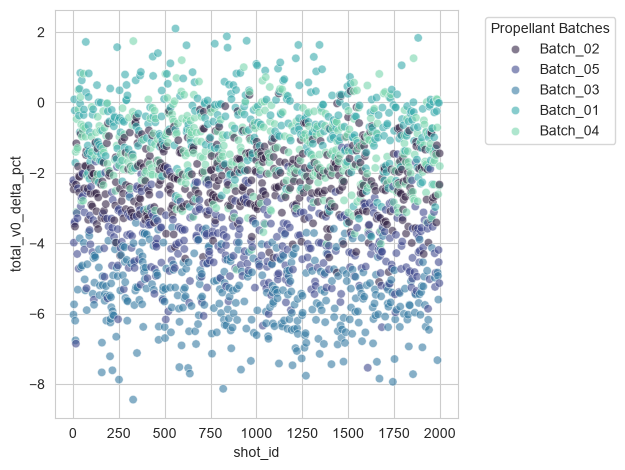

In [33]:
#Drawing points
sns.scatterplot(data=df, x='shot_id', y='total_v0_delta_pct', hue='ammunition_batches', palette='mako', alpha=0.6)

# Moving the legend to the side
plt.legend(title="Propellant Batches", bbox_to_anchor=(1.05, 1), loc='upper left')

# 4. Displaying the chart
plt.tight_layout()
plt.show()

### 📊 Key Insights from V0 Velocity Analysis

1. **Colors are grouped in lines:** On the plot, we can see that colors don't mix up randomly. Instead, they form clear horizontal layers. This tells us that the **propellant batch** is the main reason why the initial velocity ($V_0$) changes so much.
2. **How different batches perform:**
   * **Batch_04 and Batch_01** (light green and teal dots) are the best ones. They stay close to the top, meaning their velocity drop is very small (only between 0% and -2%).
   * **Batch_02 and Batch_05** (darker purple/blue dots) are in the middle. They consistently lose more velocity, around -2% to -5%.
   * **Batch_03** (light blue dots) is the worst and looks like a real anomaly. Its velocity drops heavily — down to -8%. In real life, this means the shells from this batch will likely fall short of the target.
3. **No visible barrel wear trend:** All the colored lines go straight from left to right. If the howitzer barrel was wearing out during these 2000 shots, the dots would gradually move down at the end of the chart. Since they do not, the quality of the powder is much more important here than the wear of the gun.